In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Paths
VIDEO_PATH = "../data/subject1/vid.avi"
GT_PATH    = "../data/subject1/ground_truth.txt"

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)

fps        = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration   = frame_count / fps

print("=" * 40)
print(f"  FPS          : {fps}")
print(f"  Total Frames : {frame_count}")
print(f"  Resolution   : {width} x {height}")
print(f"  Duration     : {duration:.2f} seconds")
print("=" * 40)

cap.release()

  FPS          : 29.264106
  Total Frames : 1547
  Resolution   : 640 x 480
  Duration     : 52.86 seconds


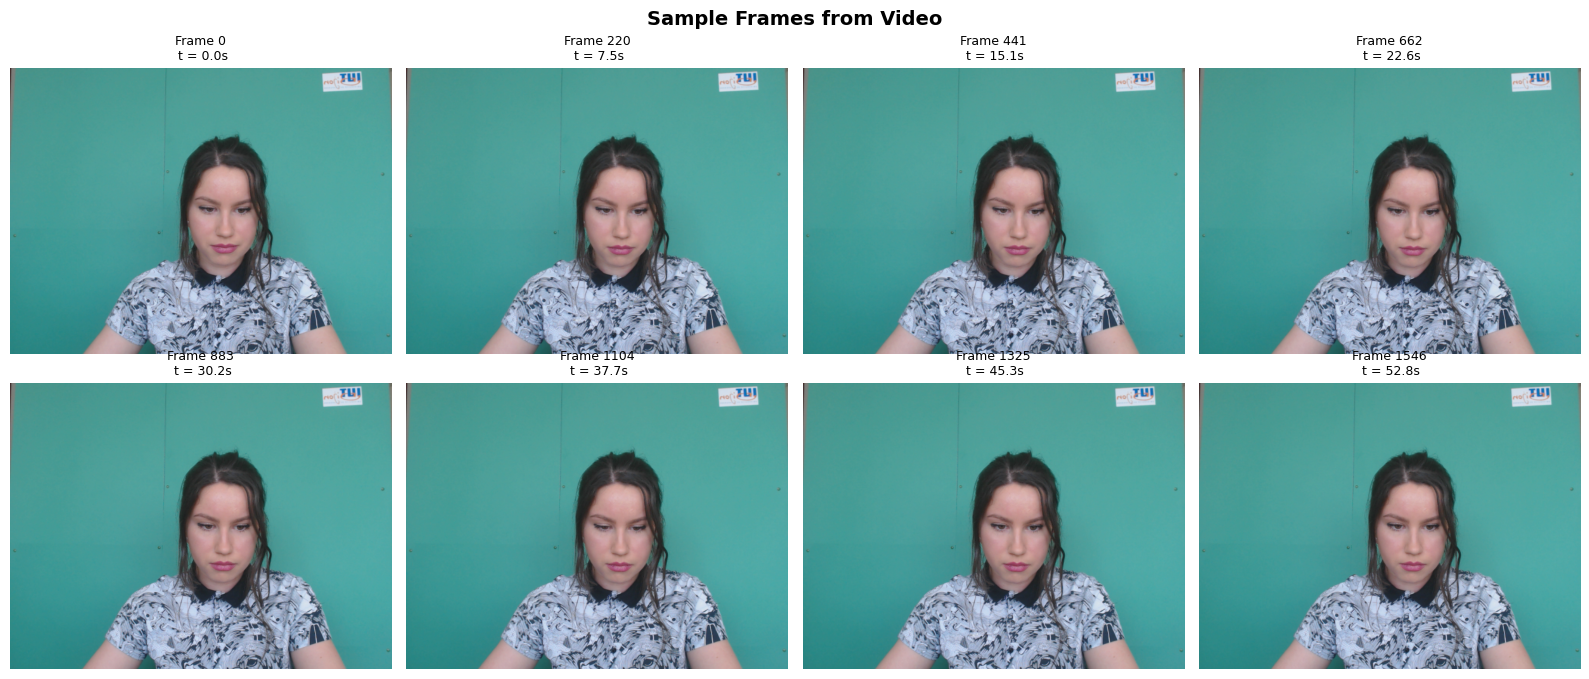

Saved → outputs/sample_frames.png


In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)

# Pick 8 evenly spaced frames
sample_indices = np.linspace(0, frame_count - 1, 8, dtype=int)
frames = []

for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((idx, frame_rgb))

cap.release()

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Sample Frames from Video", fontsize=14, fontweight='bold')

for ax, (idx, frame) in zip(axes.flatten(), frames):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}\n t = {idx/fps:.1f}s", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig("../outputs/sample_frames.png", dpi=150)
plt.show()
print("Saved → outputs/sample_frames.png")

In [4]:
# UBFC ground_truth.txt: row 0 = PPG signal, row 1 = HR values
gt_data = np.loadtxt(GT_PATH)

ppg_signal = gt_data[0]   # raw BVP/PPG waveform
hr_values  = gt_data[1]   # heart rate over time

# Time axis (sampled at same fps as video)
t = np.arange(len(ppg_signal)) / fps

print(f"PPG signal length : {len(ppg_signal)} samples")
print(f"HR values length  : {len(hr_values)} samples")
print(f"HR range          : {hr_values.min():.1f} – {hr_values.max():.1f} BPM")
print(f"Mean HR           : {hr_values.mean():.1f} BPM")

PPG signal length : 1547 samples
HR values length  : 1547 samples
HR range          : 97.0 – 113.0 BPM
Mean HR           : 106.7 BPM


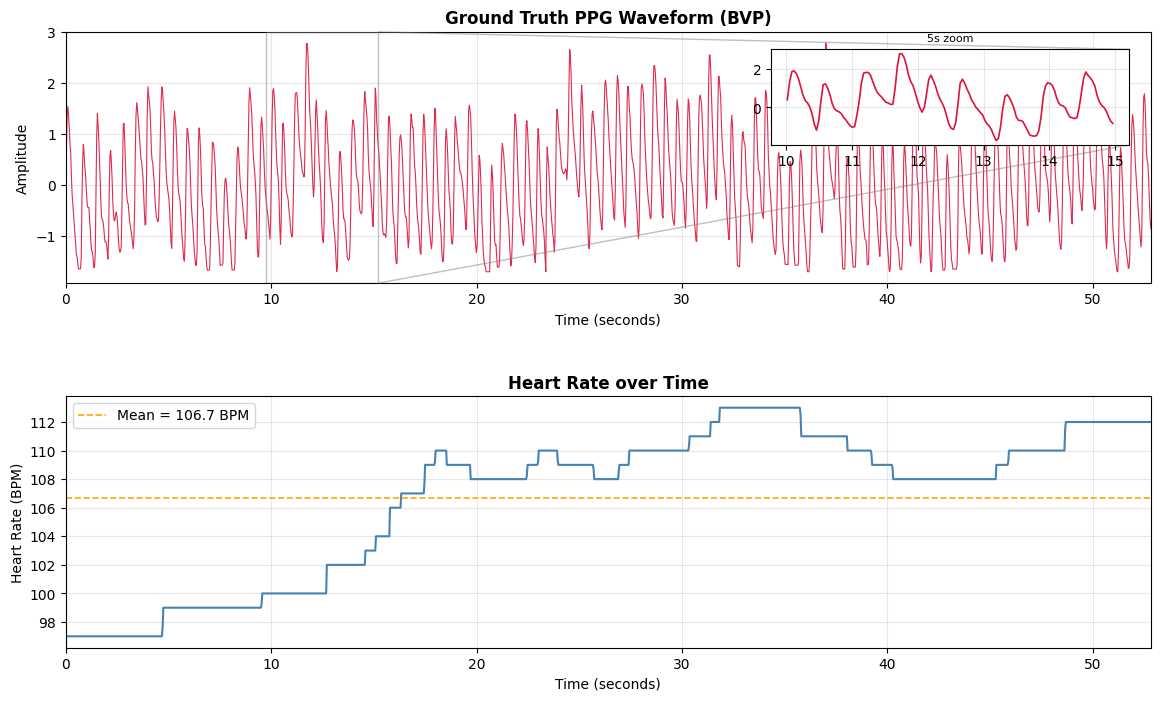

Saved → outputs/ground_truth_signals.png


In [5]:
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 1, hspace=0.45)

# --- PPG Waveform ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(t, ppg_signal, color='crimson', linewidth=0.8, alpha=0.9)
ax1.set_title("Ground Truth PPG Waveform (BVP)", fontweight='bold')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Amplitude")
ax1.set_xlim([t[0], t[-1]])
ax1.grid(True, alpha=0.3)

# Zoom inset — show 5 seconds clearly
ax1_inset = ax1.inset_axes([0.65, 0.55, 0.33, 0.38])
mask = (t >= 10) & (t <= 15)
ax1_inset.plot(t[mask], ppg_signal[mask], color='crimson', linewidth=1.2)
ax1_inset.set_title("5s zoom", fontsize=8)
ax1_inset.grid(True, alpha=0.3)
ax1.indicate_inset_zoom(ax1_inset, edgecolor="gray")

# --- Heart Rate over Time ---
ax2 = fig.add_subplot(gs[1])
t_hr = np.arange(len(hr_values)) / fps
ax2.plot(t_hr, hr_values, color='steelblue', linewidth=1.5)
ax2.axhline(hr_values.mean(), color='orange', linestyle='--',
            linewidth=1.2, label=f'Mean = {hr_values.mean():.1f} BPM')
ax2.set_title("Heart Rate over Time", fontweight='bold')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Heart Rate (BPM)")
ax2.set_xlim([t_hr[0], t_hr[-1]])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.savefig("../outputs/ground_truth_signals.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/ground_truth_signals.png")

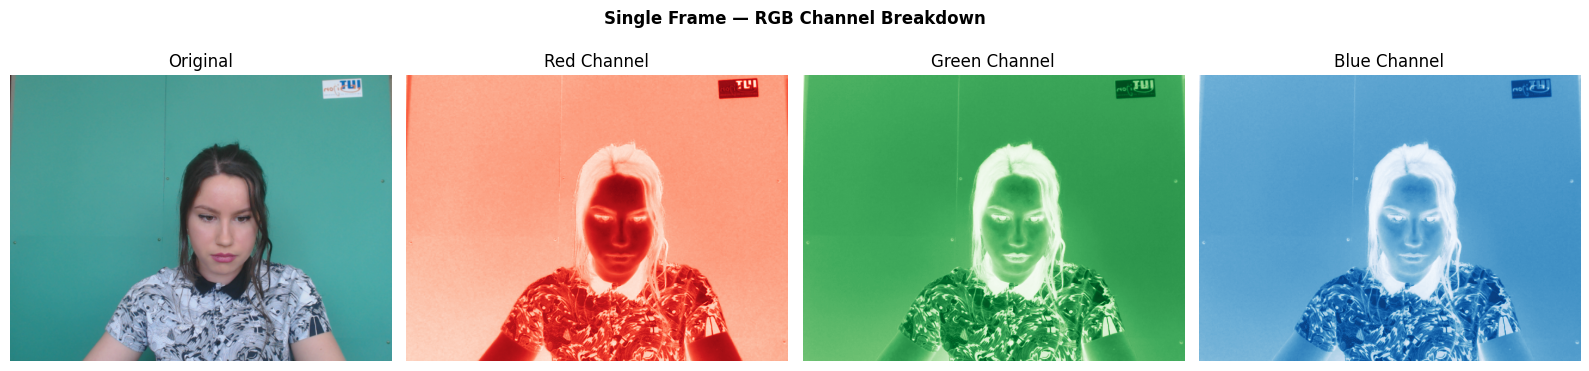


Mean pixel values at frame 773:
  R: 89.26   G: 149.90   B: 149.55

💡 Notice: Green channel carries the strongest pulse signal!


In [6]:
# Look at one frame in detail — RGB channels separately
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
R, G, B   = frame_rgb[:,:,0], frame_rgb[:,:,1], frame_rgb[:,:,2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Single Frame — RGB Channel Breakdown", fontweight='bold')

axes[0].imshow(frame_rgb);             axes[0].set_title("Original");  axes[0].axis('off')
axes[1].imshow(R, cmap='Reds');        axes[1].set_title("Red Channel");   axes[1].axis('off')
axes[2].imshow(G, cmap='Greens');      axes[2].set_title("Green Channel"); axes[2].axis('off')
axes[3].imshow(B, cmap='Blues');       axes[3].set_title("Blue Channel");  axes[3].axis('off')

plt.tight_layout()
plt.savefig("../outputs/rgb_channels.png", dpi=150)
plt.show()

print(f"\nMean pixel values at frame {frame_count//2}:")
print(f"  R: {R.mean():.2f}   G: {G.mean():.2f}   B: {B.mean():.2f}")
print("\n💡 Notice: Green channel carries the strongest pulse signal!")